Set up dataset construction parameters

In [1]:
import json
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from medpy.io import load

CONFIG = {
    "database_path": "../Fetal/PSFHS",
    "output_path": "../Dataset/PSFHS/Landmarks_3_10",
    "scale_factor": 0.10, # 10% of the original average contour size
    "resolutions": ["full", "half", "quarter"], # Names are only for reference
    # "resolutions": [1, 1/2, 1/4], # Actual scale factors
    "image_types": [""],  
    "organs": ["1", "2"], # ID in the mask
    "organ_names": ["Pubic symphysis", "Fetal head"], # Name ID
    "inputsize": 512
}

os.makedirs(CONFIG["output_path"], exist_ok=True)
with open(os.path.join(CONFIG["output_path"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=4)

First, we organize the dataset in folders:

images/ ...

masks/ ...

This reorganization is not required if the masks are provided in a file, with a list of paths.

In [2]:
def organize_dataset(config):
    """
    Organizes the dataset into images and masks folders and creates a file list.
    
    Args:
    config (dict): Configuration dictionary containing paths and other settings.
    
    Returns:
    tuple: (image_list_path, mask_list_path)
    """
    image_dir = Path(config['output_path']) / 'images'
    mask_dir = Path(config['output_path']) / 'masks'
    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)
    
    image_list = []
    mask_list = []
    
    # This part will need to be adapted for each specific dataset
    for image_path in Path(os.path.join(config['database_path'], "image_mha")).iterdir():
        print(f"Processing {image_path}")

        mask_path = Path(str(image_path).replace("image_mha", "label_mha"))
        
        image_array, _ = load(image_path)
        image_array = image_array.mean(axis=2)
        mask_array, _ = load(mask_path)

        image_array = cv2.rotate(image_array, cv2.ROTATE_90_CLOCKWISE)
        mask_array = cv2.rotate(mask_array, cv2.ROTATE_90_CLOCKWISE)
        
        cv2.imwrite(str(image_dir / image_path.name.replace(".mha", ".png")), image_array)
        cv2.imwrite(str(mask_dir / mask_path.name.replace(".mha", ".png")), mask_array)      
        
        # set paths relative to the output directory
        image_path = image_path.relative_to(os.path.join(config['database_path'], "image_mha"))
        mask_path = mask_path.relative_to(os.path.join(config['database_path'], "label_mha"))
        
        image_list.append(str(image_path.name.replace(".mha", ".png")))
        mask_list.append(str(mask_path.name.replace(".mha", ".png")))
    
    # Write file lists
    image_list_path = Path(config['output_path']) / 'image_list.txt'
    mask_list_path = Path(config['output_path']) / 'mask_list.txt'
    
    with open(image_list_path, 'w') as f:
        f.write('\n'.join(image_list))
    with open(mask_list_path, 'w') as f:
        f.write('\n'.join(mask_list))
    
    return

In [3]:
# Step 1: Organize dataset
organize_dataset(CONFIG)

Processing ../Fetal/PSFHS/image_mha/01983.mha
Processing ../Fetal/PSFHS/image_mha/03896.mha
Processing ../Fetal/PSFHS/image_mha/01925.mha
Processing ../Fetal/PSFHS/image_mha/02317.mha
Processing ../Fetal/PSFHS/image_mha/00837.mha
Processing ../Fetal/PSFHS/image_mha/04495.mha
Processing ../Fetal/PSFHS/image_mha/04075.mha
Processing ../Fetal/PSFHS/image_mha/03988.mha
Processing ../Fetal/PSFHS/image_mha/02797.mha
Processing ../Fetal/PSFHS/image_mha/00273.mha
Processing ../Fetal/PSFHS/image_mha/02337.mha
Processing ../Fetal/PSFHS/image_mha/04086.mha
Processing ../Fetal/PSFHS/image_mha/02013.mha
Processing ../Fetal/PSFHS/image_mha/03393.mha
Processing ../Fetal/PSFHS/image_mha/00649.mha
Processing ../Fetal/PSFHS/image_mha/04392.mha
Processing ../Fetal/PSFHS/image_mha/03696.mha
Processing ../Fetal/PSFHS/image_mha/04783.mha
Processing ../Fetal/PSFHS/image_mha/02421.mha
Processing ../Fetal/PSFHS/image_mha/02256.mha
Processing ../Fetal/PSFHS/image_mha/01808.mha
Processing ../Fetal/PSFHS/image_mh

Then the landmarks can be directly generated from the masks.

In [3]:
from utils.image_processing import generate_landmark_contours, get_contour_lengths

# Step 2: Generate landmark contours
generate_landmark_contours(CONFIG)

# Step 3: Get contour lengths
contour_lengths = get_contour_lengths(CONFIG, os.path.join(CONFIG["output_path"], "landmarks"))

Loading image list from ../Dataset/PSFHS/Landmarks_3_10/image_list.txt
Loading mask list from ../Dataset/PSFHS/Landmarks_3_10/mask_list.txt
Generating landmarks for 5101 images.


Contour lengths:
Organ 1: min=73, max=202, avg=118.92
Organ 2: min=184, max=476, avg=314.82


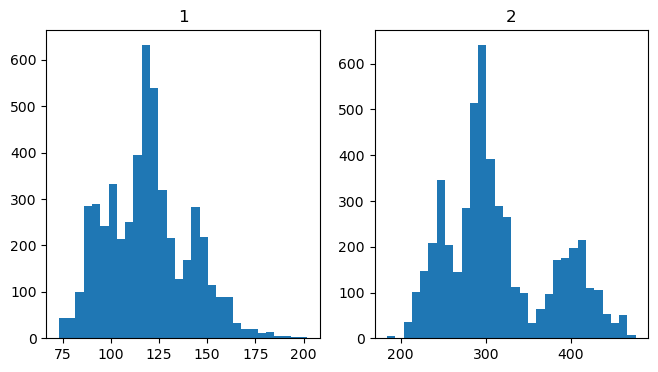

In [4]:
print("Contour lengths:")
for organ, lengths in contour_lengths.items():
    print(f"Organ {organ}: min={min(lengths)}, max={max(lengths)}, avg={sum(lengths)/len(lengths):.2f}")

plt.figure(figsize=(12, 4))

for i, j in enumerate(contour_lengths.keys()):
    plt.subplot(1, 3, i+1)
    plt.hist(contour_lengths[j], bins=30)
    plt.title(j)

/tmp/ipykernel_235305/2460824885.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


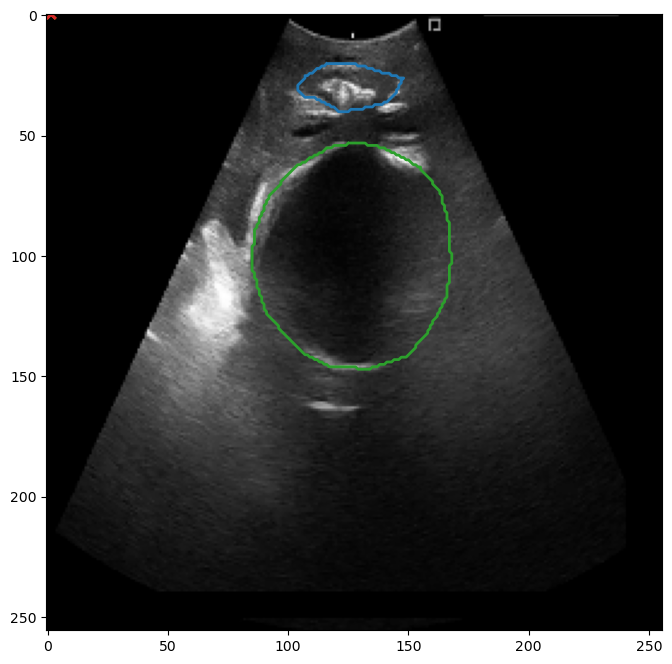

In [2]:
import numpy as np

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

id = 25

image_path = Path(CONFIG['output_path']) / 'images' / image_list[id]
mask_path = Path(CONFIG['output_path']) / 'masks' / image_list[id]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / Path(image_list[id]).with_suffix('.json')

image = cv2.imread(str(image_path))
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
landmarks = json.load(open(landmarks_path))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)

/tmp/ipykernel_235305/1458518297.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


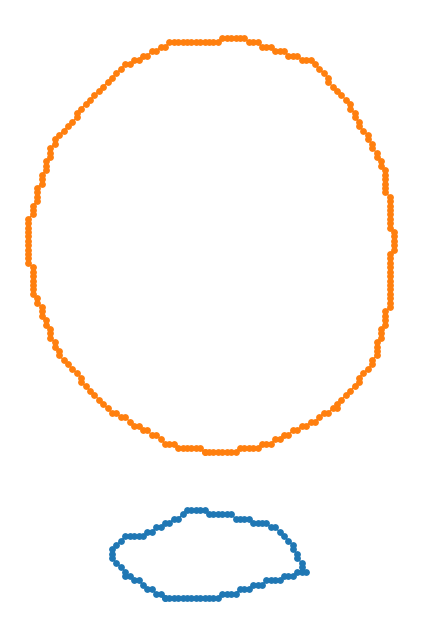

In [19]:
plt.figure(figsize=(8, 8))
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    # connect the contour points
    contour = np.array(contour)
    if contour.shape[0] > 1:
        # Ensure the contour is closed by connecting the last point to the first
        if not np.array_equal(contour[0], contour[-1]):
            contour = np.vstack([contour, contour[0]])
    plt.scatter(contour[:, 0], contour[:, 1], s=15)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], lw=1)
    plt.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    

The following code generates the required adjacency matrixes to run the code, from the dictionary of contour lengths.

In [18]:
from utils.matrix_ops import generate_adjacency_matrices, save_matrices, create_sampling_matrix, generate_edge_info

adjacency_matrices, downsampling_matrices, upsampling_matrices = generate_adjacency_matrices(contour_lengths, CONFIG)

for res in CONFIG["resolutions"]:
    save_matrices(adjacency_matrices[res], res, CONFIG)

for name, matrices in downsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/downsampling_{name}.npy", block_matrix)

for name, matrices in upsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/upsampling_{name}.npy", block_matrix)

generate_edge_info(CONFIG)

Organ 1 - Contour len mean: 118.91785924328563 - Atlas contour size: 32
Adjacency matrices sizes: [('full', 32), ('half', 16)]
Downsampling matrices sizes: [('to_half', 16)]
Organ 2 - Contour len mean: 314.8194471672221 - Atlas contour size: 32
Adjacency matrices sizes: [('full', 32), ('half', 16)]
Downsampling matrices sizes: [('to_half', 16)]


Separate splits in training, validation and test

In [8]:
# Load the files .txt and separate them in training validation and test. Use a 80 - 10 - 10 split
import numpy as np
import random

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'

with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
# samples should be taking without putting the same patient in different sets
# the list contains files in the format patient/type/image.png
# so first separate the files by patient

patients = {}
for image in image_list:
    patient = image.split('/')[0]
    if patient not in patients:
        patients[patient] = []
    patients[patient].append(image)

# now we have a dictionary with the patient as key and a list of images as value
# we can now split the patients in training, validation and test
# we will use a 80 - 10 - 10 split

n_patients = len(patients)
n_train = int(0.8 * n_patients)
n_test = int(0.1 * n_patients)
n_val = n_patients - n_train - n_test

random.seed(42)
patients = list(patients.items())
patients = sorted(patients)  # Sort by number of images per patient

train_patients = patients[:n_train]
val_patients = patients[n_train:n_train+n_val]
test_patients = patients[n_train+n_val:]

train_images = []
val_images = []
test_images = []

for patient, images in train_patients:
    train_images.extend(images)
for patient, images in val_patients:
    val_images.extend(images)
for patient, images in test_patients:
    test_images.extend(images)

# save as txt

train_image_list_path = Path(CONFIG['output_path']) / 'train.txt'
val_image_list_path = Path(CONFIG['output_path']) / 'val.txt'
test_image_list_path = Path(CONFIG['output_path']) / 'test.txt'

with open(train_image_list_path, 'w') as f:
    f.write('\n'.join(train_images))
with open(val_image_list_path, 'w') as f:
    f.write('\n'.join(val_images))
with open(test_image_list_path, 'w') as f:
    f.write('\n'.join(test_images))